In [432]:
root_dir = '../../result/bootstrap_stats_phys/'

In [433]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from scipy.optimize import curve_fit   
plt.style.use('../../code/style.mplstyle')
from collections import defaultdict
from matplotlib import cm

In [434]:


def load_all_z(dir, snaps):
    all_z = []
    for snap in snaps:
        data = np.load(dir+f'/snap_{snap}_Rsp_stats.npy', allow_pickle=True).item()
        all_z.append(np.round(data['z'], 1))
    return all_z

def load_z(dir, snaps):
    data = np.load(dir+f'/snap_{min(snaps)}_Rsp_stats.npy', allow_pickle=True).item()
    z_i = np.round(data['z'], 1)
    data = np.load(dir+f'/snap_{max(snaps)}_Rsp_stats.npy', allow_pickle=True).item()
    z_f = np.round(data['z'], 1)
    return z_i, z_f

In [435]:
TNG300_snaps = [99, 78, 67, 50, 40, 33, 25, 21, 17, 13, 8]
TNG300_dir = f'{root_dir}/TNG300/sim_205_1250_Hydro/Nboots_1024/'
TNG300_z_i, TNG300_z_f = load_z(TNG300_dir, TNG300_snaps)

MTNG_snaps = [264, 237, 214, 179, 151, 129]
MTNG_dir = f'{root_dir}/MTNG/Hydro-Arepo/MTNG-L500-4320-A/Nboots_1024/'
MTNG_z_i, MTNG_z_f = load_z(MTNG_dir, MTNG_snaps)

In [436]:
def load_stats(dir, snap, data_name):
    data = np.load(f'{dir}/snap_{snap}_Rsp_stats.npy', allow_pickle=True).item()

    z             = np.round(data['z'], 1)
    mass_bins     = [10**(10+mass) for mass in data['mass_bins']]
    final_results = data['final_results']
    
    if data_name == 'Rsp':
        data_idx = 0
    elif data_name == 'depth':
        data_idx = 1
    elif data_name == 'width':
        data_idx = 2
    elif data_name == 'phys_width':
        data_idx = 3
    
    y = final_results[:, data_idx, 1]
    y_err = [final_results[:, data_idx, 1]-final_results[:, data_idx, 0], 
             final_results[:, data_idx, 2]-final_results[:, data_idx, 1]]
    avg_y_err = np.mean(y_err, axis=0)
    return z, np.array(mass_bins), np.array(y), np.array(avg_y_err)

In [437]:
simus = ['Hydro']

all_z, all_mass_bins, all_y, all_yerr = [], [], [], []
for simu in simus:
        
    # TNG300
    for snap in TNG300_snaps:
        TNG300_dir = f'{root_dir}/TNG300/sim_205_1250_{simu}/Nboots_1024/'
        TNG300_z, TNG300_mass_bins, TNG300_y, TNG300_yerr = load_stats(TNG300_dir, snap, 'depth')
        print(TNG300_z, TNG300_mass_bins.shape, TNG300_y.shape, TNG300_yerr.shape)
        all_z.append(TNG300_z)
        all_mass_bins.append(TNG300_mass_bins)
        all_y.append(TNG300_y)
        all_yerr.append(TNG300_yerr)
            
    # MTNG
    for snap in MTNG_snaps:
        MTNG_dir = f'{root_dir}/MTNG/{simu}-Arepo/MTNG-L500-4320-A/Nboots_1024/'
        MTNG_z, MTNG_mass_bins, MTNG_y, MTNG_yerr = load_stats(MTNG_dir, snap, 'depth')
        print(MTNG_z, MTNG_mass_bins.shape, MTNG_y.shape, MTNG_yerr.shape)
        all_z.append(MTNG_z)
        all_mass_bins.append(MTNG_mass_bins)
        all_y.append(MTNG_y)
        all_yerr.append(MTNG_yerr)


0.0 (8,) (8,) (8,)
0.3 (8,) (8,) (8,)
0.5 (8,) (8,) (8,)
1.0 (7,) (7,) (7,)
1.5 (7,) (7,) (7,)
2.0 (6,) (6,) (6,)
3.0 (6,) (6,) (6,)
4.0 (5,) (5,) (5,)
5.0 (4,) (4,) (4,)
6.0 (3,) (3,) (3,)
8.0 (2,) (2,) (2,)
0.0 (5,) (5,) (5,)
0.2 (5,) (5,) (5,)
0.5 (5,) (5,) (5,)
1.0 (4,) (4,) (4,)
1.5 (4,) (4,) (4,)
2.0 (3,) (3,) (3,)


In [438]:
print(all_z)

[np.float64(0.0), np.float64(0.3), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(8.0), np.float64(0.0), np.float64(0.2), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0)]


### Fit mass at constant redshift

We define the function of depth $D(x)=a_0+a_1 x + a_2 x^2$ where $x = log_{10}M$. The reduced $\chi^2$ is acceptable.

In [439]:
def fit_depth_const_z(x, a0, a1, a2):
    return a0 + a1*x + a2*x**2 

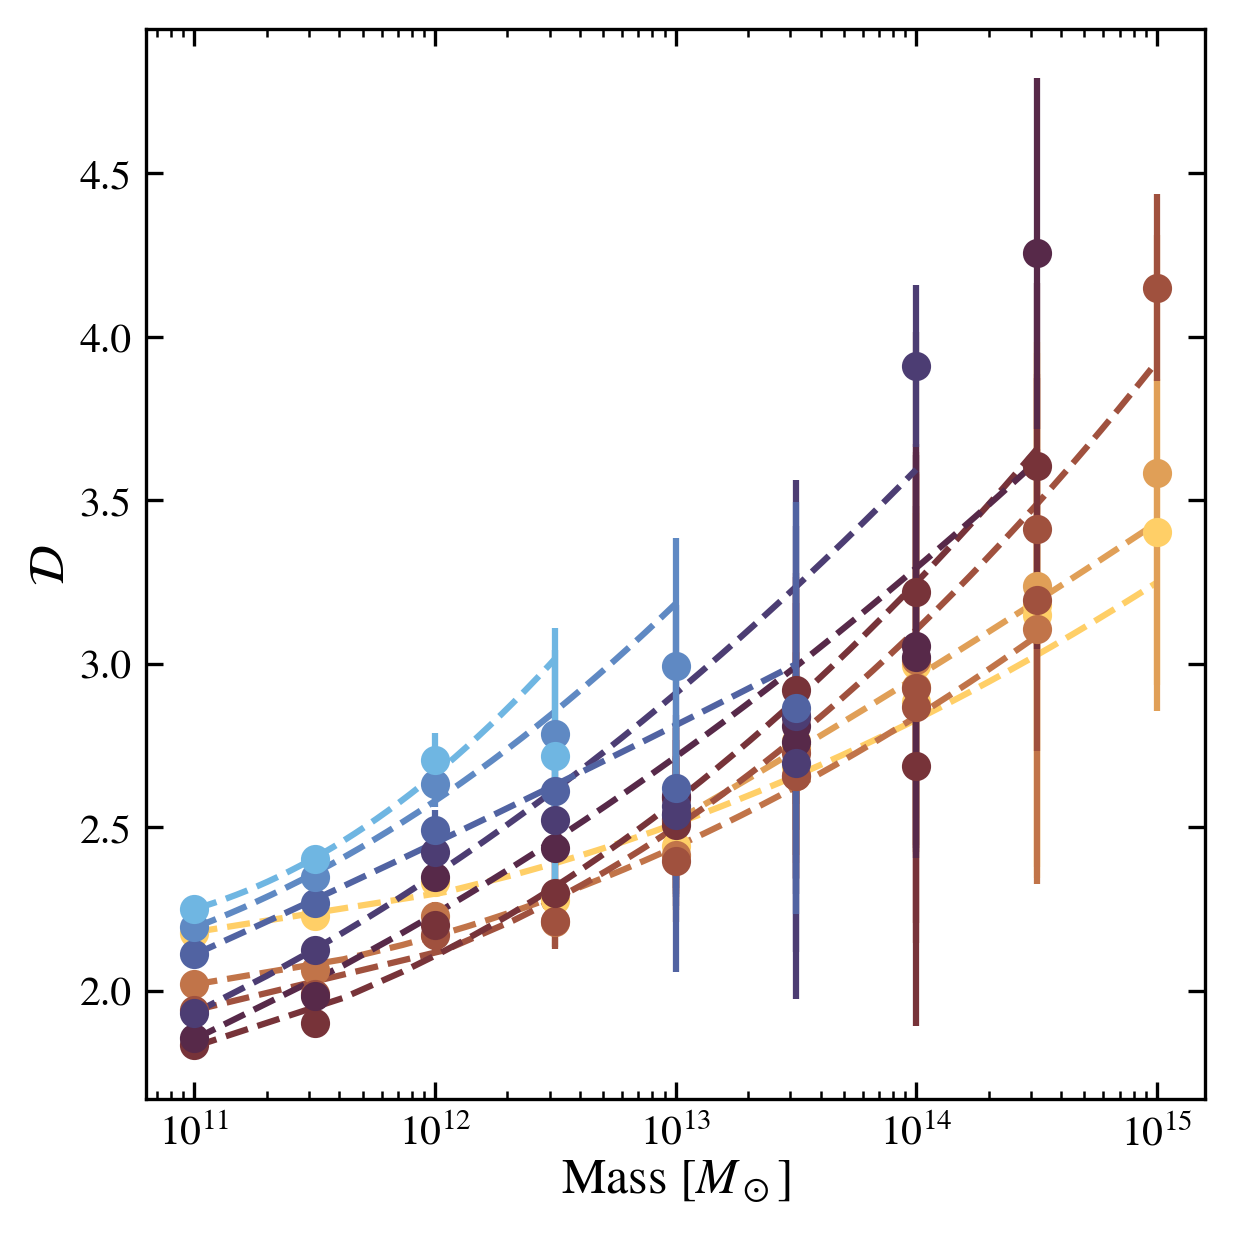

In [440]:
fig, axs = plt.figure(figsize=(4, 4)), plt.gca()
cmap = plt.get_cmap('managua', len(TNG300_snaps))
norm = BoundaryNorm(np.unique(all_z), cmap.N)

# Create a nested defaultdict structure
depth_vs_mass = defaultdict(lambda: defaultdict(list))

for z in np.unique(all_z):

    indices = np.where(all_z == z)[0]
    current_mass_bins = [all_mass_bins[idx] for idx in indices]
    current_y         = [all_y[idx] for idx in indices]
    current_yerr      = [all_yerr[idx] for idx in indices]
    
    # Concatenate data
    current_mass_bins = np.concatenate(current_mass_bins)
    current_y         = np.concatenate(current_y)
    current_yerr      = np.concatenate(current_yerr)
    
    # Sort data based on the mass bins
    sorted_indices = np.argsort(current_mass_bins)
    current_mass_bins = current_mass_bins[sorted_indices]
    current_y         = current_y[sorted_indices]
    current_yerr      = current_yerr[sorted_indices]
    
    # If there are multiple data points with the same mass, keep the value of y but change the corresponding yerr to the common max and min
    unique_mass_bins = np.unique(current_mass_bins)
    for mass in unique_mass_bins:
        indices = np.where(current_mass_bins == mass)[0]
        if len(indices) > 1:
            current_yerr[indices] = max(current_yerr[indices])
    
    # Add to dictionary
    depth_vs_mass[z]['M'] = current_mass_bins
    depth_vs_mass[z]['D'] = current_y
    depth_vs_mass[z]['D_err'] = current_yerr
    
    if current_y.shape[0] < 4:
        pass
    else:
        # Plot data
        axs.errorbar(current_mass_bins, current_y, yerr=current_yerr, fmt='o', color=cmap(norm(z)))
        
        # Curve fitting
        popt, pcov = curve_fit(fit_depth_const_z, np.log10(current_mass_bins), current_y, sigma=current_yerr, maxfev=10000)
        current_yfit = fit_depth_const_z(np.log10(current_mass_bins), *popt)
        
        red_chi2 = np.sum((current_y - current_yfit)**2 / current_yerr**2) / (len(current_y) - len(popt))
        
        # # Print the equation and the reduced chi^2
        # print(f'z = {z}')
        # print(f'Reduced chi^2 = {red_chi2:.2f}')
        # print('')
        
        # Plot the fit
        x_fit = np.linspace(current_mass_bins.min(), current_mass_bins.max(), 1000)
        y_fit = fit_depth_const_z(np.log10(x_fit), *popt)
        axs.plot(x_fit, y_fit, color=cmap(norm(z)), label=f'$chi^2_\\nu$ = {red_chi2:.2f}', ls='--')
axs.set_xscale('log')
axs.set_xlabel('Mass [$M_\\odot$]')
axs.set_ylabel(r"$\mathcal{D}$")
plt.savefig('hydro_depth_vs_mass.png')

# Save the data
depth_vs_mass = dict(depth_vs_mass)
np.save(f'{simu}_depth_vs_mass.npy', depth_vs_mass)

We assume that the coefficients are function of redshift $a_0(z)$, $a_1(z)$, $a_2(z)$, so the depth $D(x)=a_0(z) + a_1(z) x + a_2(z) x^2$.

### Fit redshift at constant mass

The function that we find is either $D(z) = b_0 + b_1(x) z + b_2(x) z^2 + b_3(x) z^3 + b_4(x) z^4 + b_5(x) z^5$ 

or $D(z) = b_0 + b_1(x) z + b_2(x) z^2 + b_3(x) z^3 + b_4(x) z^4$, where $x=\log_{10}M$.

In [441]:
# extract all unique elements in all_mass_bins which is a list of different length
uniq_mass_bins = np.unique(np.concatenate(all_mass_bins))
print(np.log10(uniq_mass_bins))

[11.  11.5 12.  12.5 13.  13.5 14.  14.5 15. ]


In [442]:
# Create a nested defaultdict structure
depth_vs_z = defaultdict(lambda: defaultdict(list))

for cut in uniq_mass_bins:
    # print('Current cut: ', np.log10(cut))
    cut_z, cut_y, cut_yerr = [], [], []
    for z, bins, y, yerr in zip(all_z, all_mass_bins, all_y, all_yerr):
        indices = np.where(bins == cut)[0]
        
        if len(indices) > 0:
            cut_z.append(z)
            cut_y.append(y[indices])
            cut_yerr.append(yerr[indices])
    cut_z = np.array(cut_z)
    cut_y = np.array(cut_y).squeeze()
    cut_yerr = np.array(cut_yerr).squeeze()
    # Save to dict
    depth_vs_z[np.log10(cut)]['z'] = cut_z
    depth_vs_z[np.log10(cut)]['D'] = cut_y
    depth_vs_z[np.log10(cut)]['Derr'] = cut_yerr
    
# Save the data
depth_vs_z = dict(depth_vs_z)
np.save(f'{simu}_depth_vs_z.npy', depth_vs_z)

In [443]:
# Def the fitting function
def fit_depth_const_mass(z, b0, b1, b2, b3, b4, b5):
    return b0 + b1*z + b2*z**2 + b3*z**3 + b4*z**4 + b5*z**5  

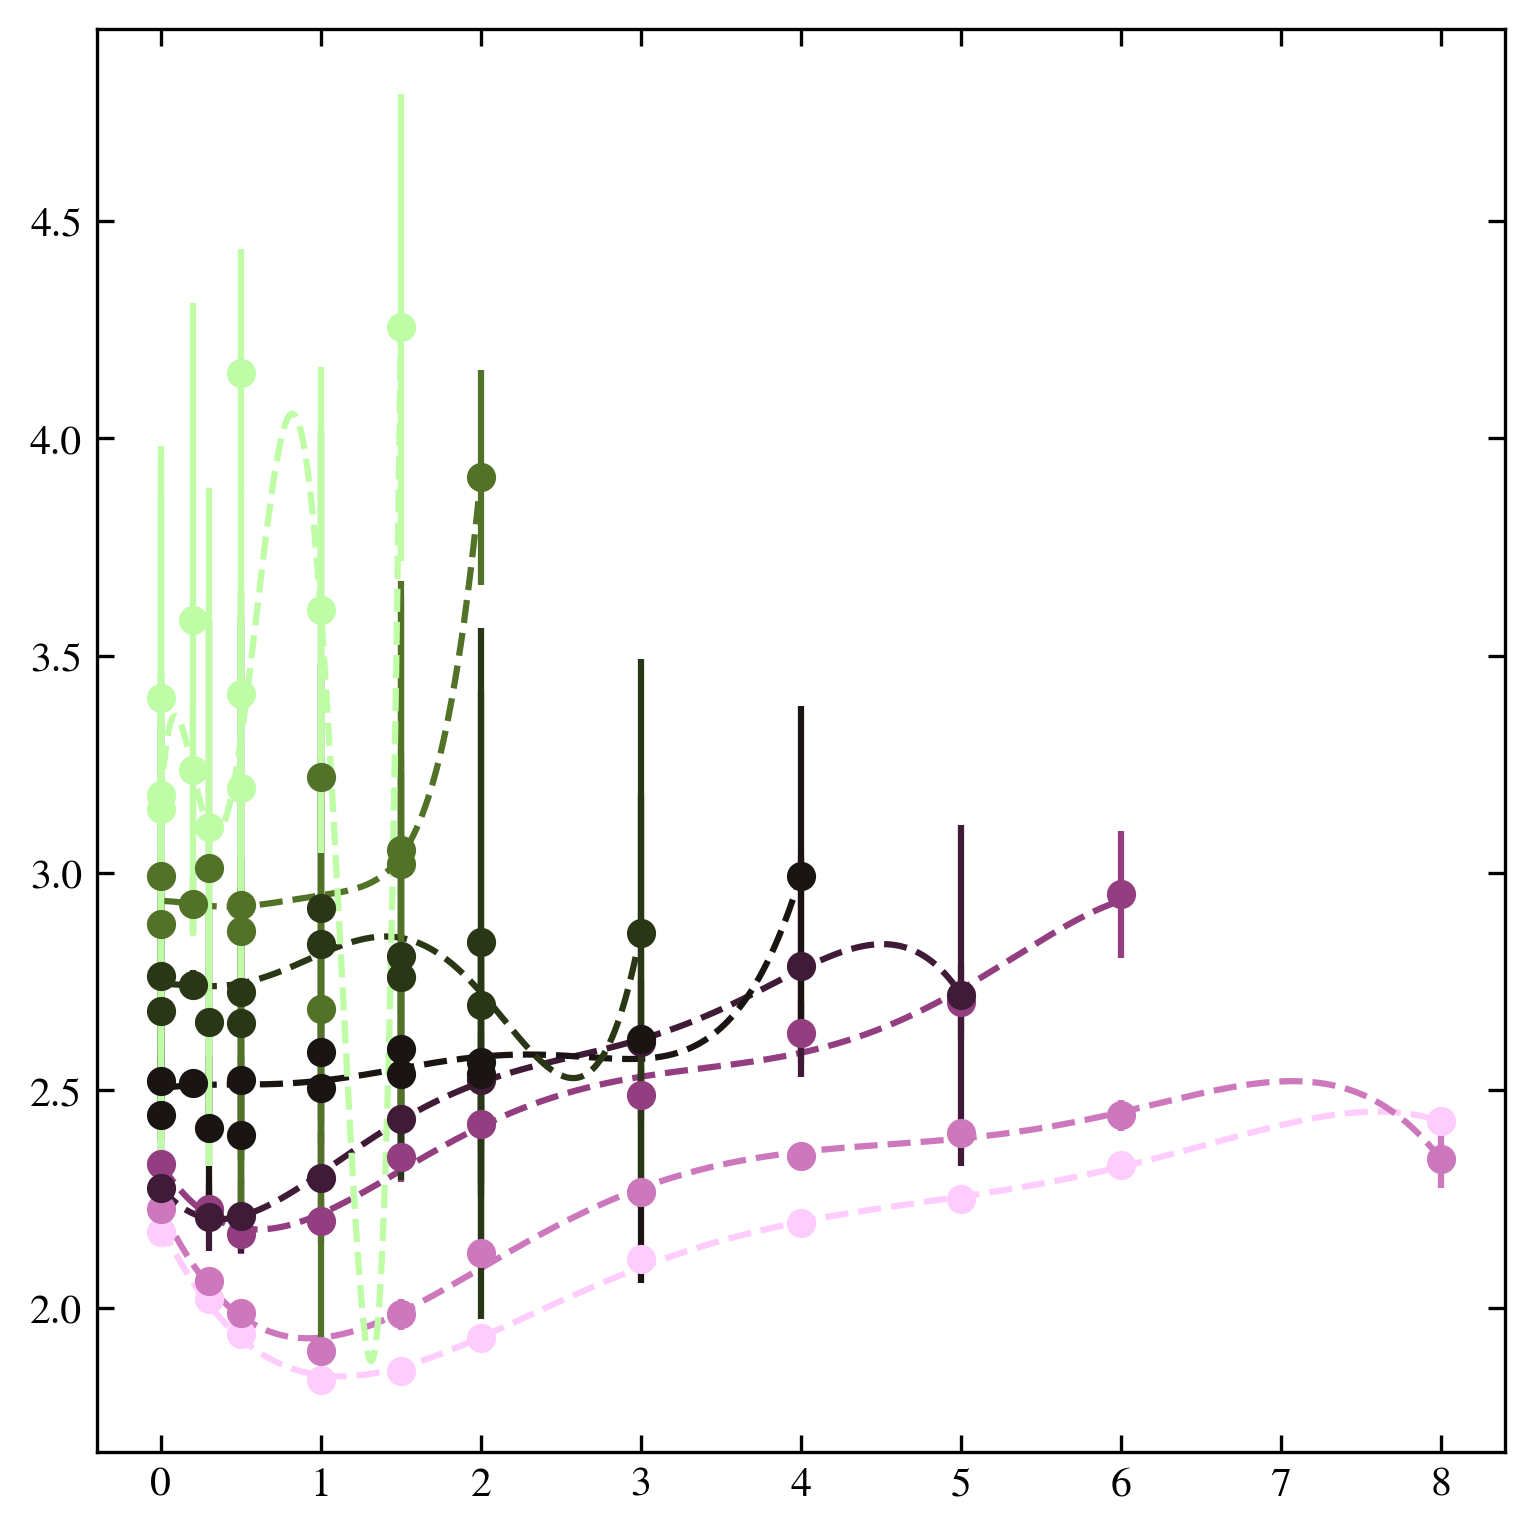

In [444]:
# Plot data
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
cmap = plt.get_cmap('vanimo', len(uniq_mass_bins))
norm = BoundaryNorm(np.log10(uniq_mass_bins), cmap.N)

for cut in uniq_mass_bins:
    cut = np.log10(cut)
    z = depth_vs_z[cut]['z']
    D = depth_vs_z[cut]['D']
    Derr = depth_vs_z[cut]['Derr']
    
    # If there are multiple data points with the z, keep the value of y but change the corresponding yerr to the common max and min
    unique_z = np.unique(z)
    for zi in unique_z:
        indices = np.where(z == zi)[0]
        if len(indices) > 1:
            Derr[indices] = max(Derr[indices])
    
    axs.errorbar(z, D, yerr=Derr, fmt='o', color=cmap(norm(cut)))
    
    # Curve fitting
    if len(z) < 4:
        pass
    else:
        popt, pcov = curve_fit(fit_depth_const_mass, z, D, sigma=Derr, maxfev=1000000)
        Dfit = fit_depth_const_mass(z, *popt)
        
        red_chi2 = np.sum((D - Dfit)**2 / Derr**2) / (len(D) - len(popt))
        
        # # Print the equation and the reduced chi^2
        # print(f'cut = {cut}')
        # print(f'Reduced chi^2 = {red_chi2:.2f}')
        # print('')
        
        # Plot the fit
        z_fit = np.linspace(z.min(), z.max(), 1000)
        D_fit = fit_depth_const_mass(z_fit, *popt)
        axs.plot(z_fit, D_fit, color=cmap(norm(cut)), label=f'$chi^2_\\nu$ = {red_chi2:.2f}', ls='--')

### Fit mass and redshift simultaneously

In [445]:
def fit_mass_and_z(inputs, 
                   c0, c1, c2, c3, c4, c5, c7, c8, c9, c12, c13, c14, c18, c19, c25):
    z, x = inputs
    eq0 = c0
    eq1 = c1*x + c2*z
    eq2 = c3*x**2 + c4*x*z + c5*z**2 
    eq3 = c7*x**2*z + c8*x*z**2 + c9*z**3
    eq4 = c12*x**2*z**2 + c13*x*z**3 + c14*z**4
    eq5 = c18*x**2*z**3 + c19*x*z**4
    eq5 = c25*x**2*z**4
    return eq0 + eq1 + eq2 + eq3 + eq4 + eq5

In [446]:
# Load all data at once
tot_z, tot_mass_bins, tot_y, tot_yerr = [], [], [], []
for cut in uniq_mass_bins:
    z = depth_vs_z[np.log10(cut)]['z'] 
    D = depth_vs_z[np.log10(cut)]['D']
    Derr = depth_vs_z[np.log10(cut)]['Derr']
    mass_cut = np.repeat(cut, len(z))

    tot_z.append(z)
    tot_mass_bins.append(mass_cut)
    tot_y.append(D)
    tot_yerr.append(Derr)
# Concatenate
tot_z = np.concatenate(tot_z)
tot_mass_bins = np.concatenate(tot_mass_bins)
tot_y = np.concatenate(tot_y)
tot_yerr = np.concatenate(tot_yerr)
print(tot_z.shape)
print(tot_mass_bins.shape)
print(tot_y.shape)
print(tot_yerr.shape)

(90,)
(90,)
(90,)
(90,)


In [447]:
# Curve fitting
popt, _ = curve_fit(fit_mass_and_z, (tot_z, np.log10(tot_mass_bins)), ydata=tot_y, sigma=tot_yerr,
                    maxfev=10000000)
tot_yfit = fit_mass_and_z((tot_z, np.log10(tot_mass_bins)), *popt)
red_chi2 = np.sum((tot_y - tot_yfit)**2 / tot_yerr**2) / (len(tot_y) - len(popt))
print(f'Reduced chi^2 = {red_chi2:.2f}')

Reduced chi^2 = 1.31


/tmp/ipykernel_2205340/2484860639.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(fit_mass_and_z, (tot_z, np.log10(tot_mass_bins)), ydata=tot_y, sigma=tot_yerr,


(90,) (90,) (90, 90)


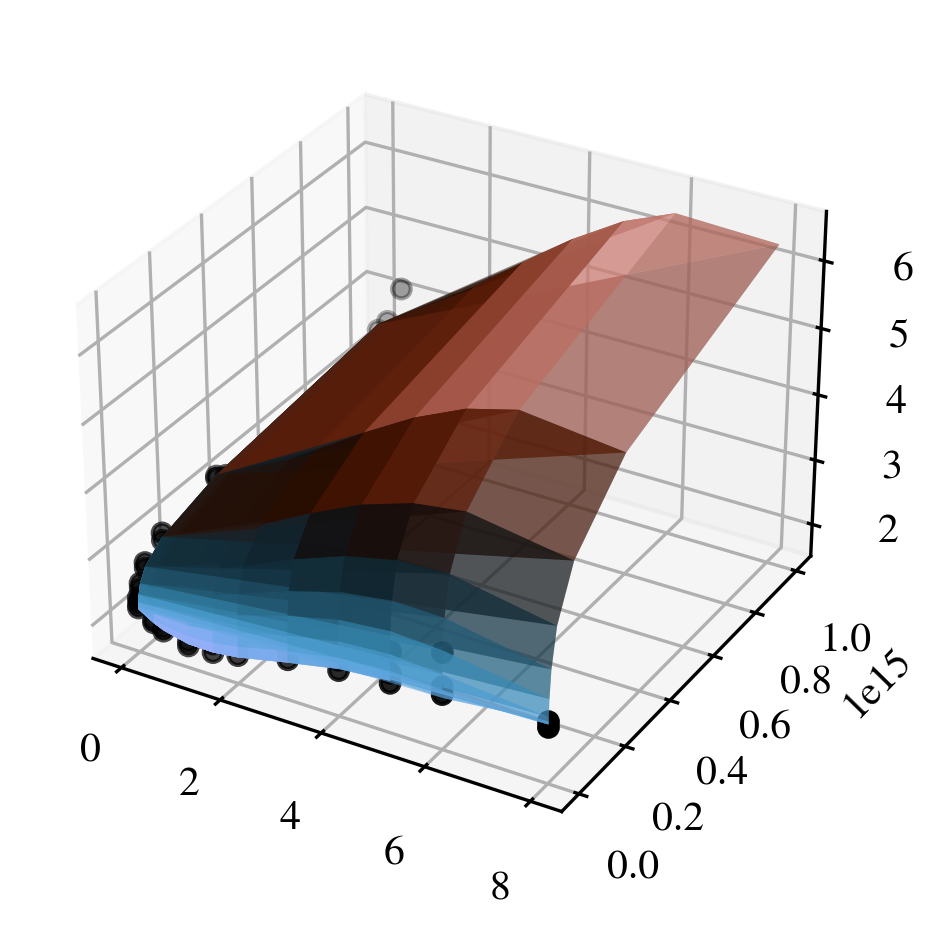

In [448]:
z_fit = tot_z
mass_fit = tot_mass_bins
Z, M = np.meshgrid(z_fit, mass_fit)
D_fit = fit_mass_and_z((Z, np.log10(M)), *popt)
print(z_fit.shape, mass_fit.shape, D_fit.shape)

# Plot the 3d fit
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Z, M, D_fit, cmap='berlin', alpha=0.5)
ax.scatter(tot_z, tot_mass_bins, tot_y, color='black')

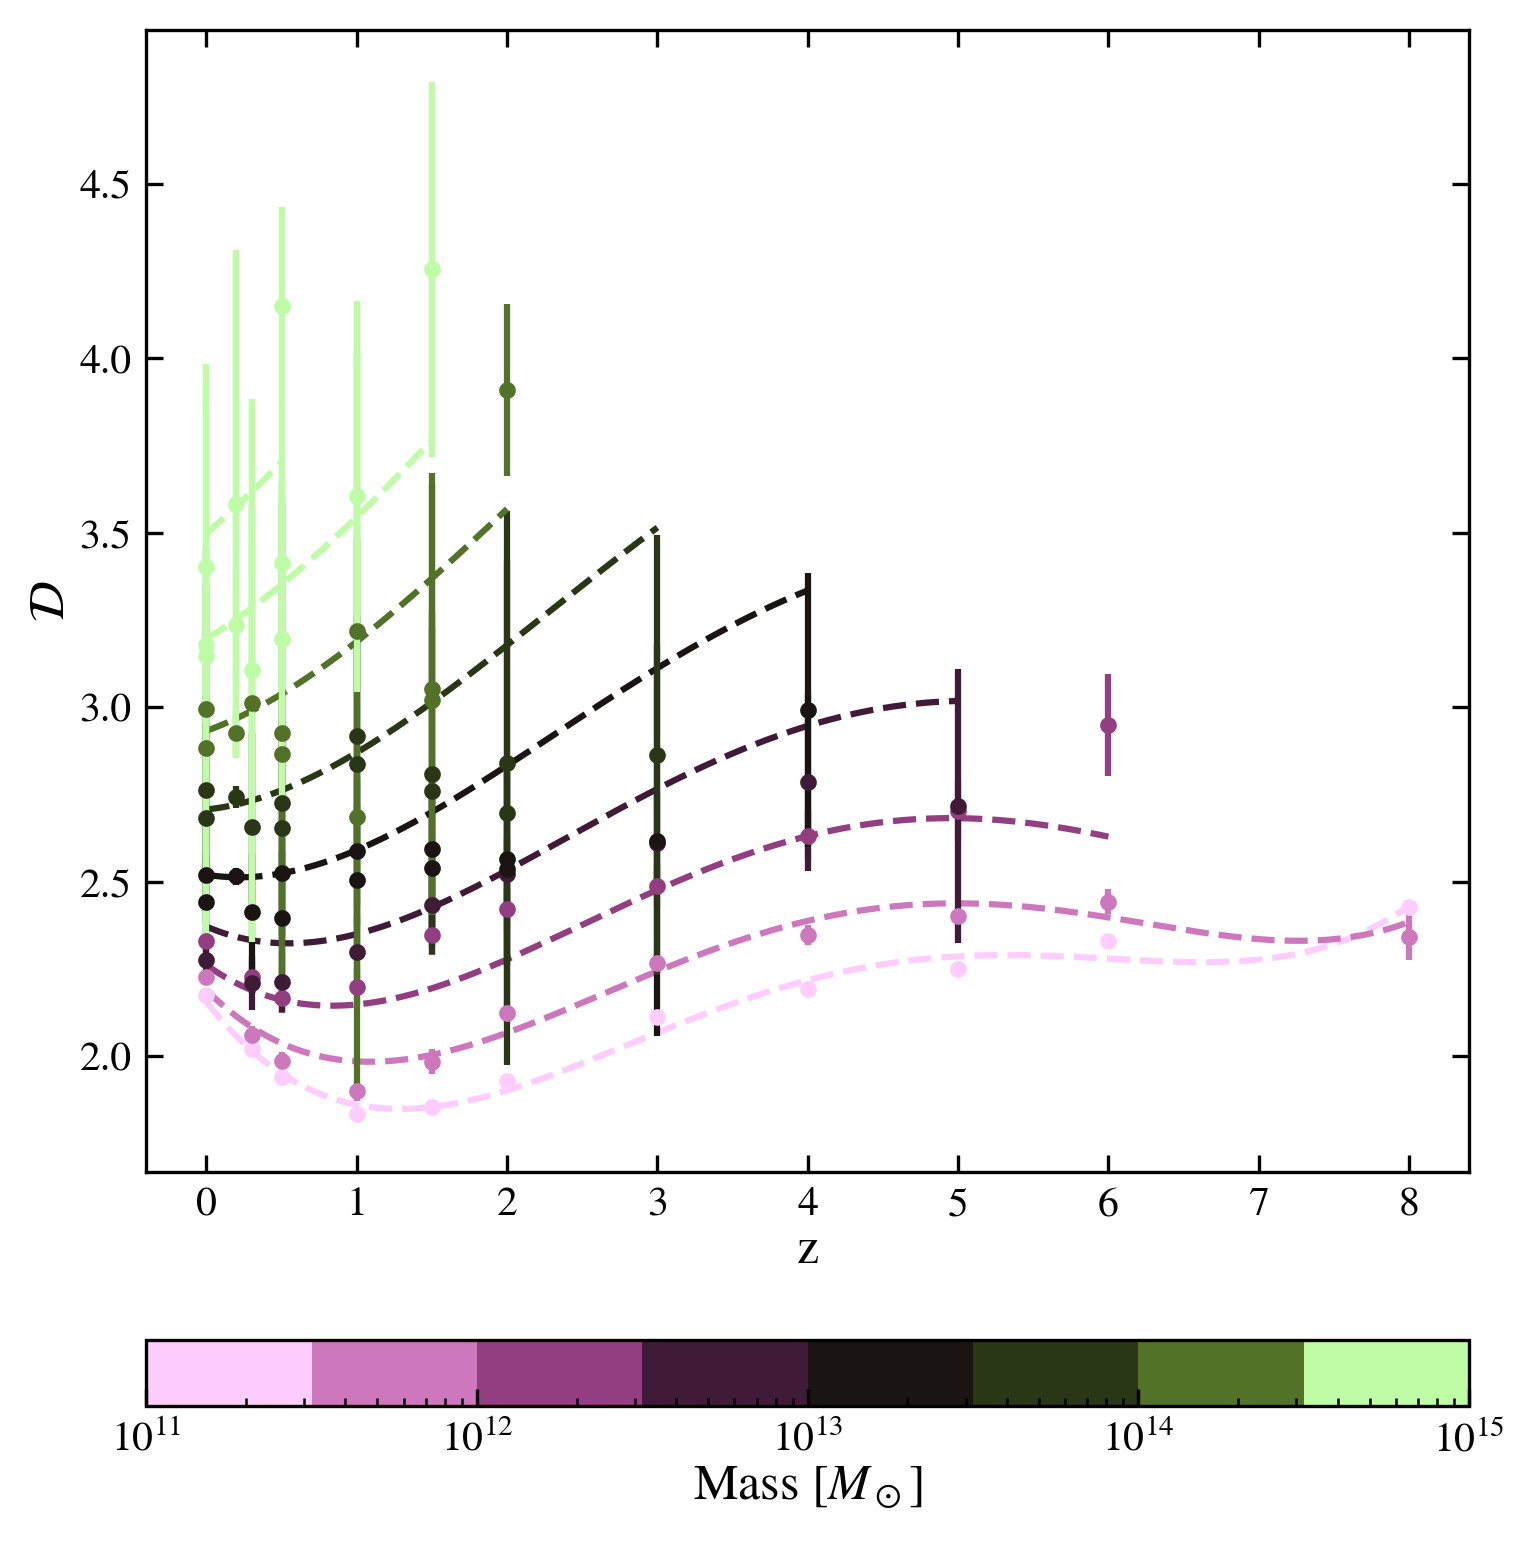

In [449]:
# Plot both x axis project and y axis project
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
cmap = plt.get_cmap('vanimo', len(uniq_mass_bins))
norm = BoundaryNorm(uniq_mass_bins, cmap.N)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                  ax=axs, orientation='horizontal', spacing='proportional', ticks=uniq_mass_bins)
cb.set_label('Mass [$M_\\odot$]')
cb._set_scale('log')

for cut in uniq_mass_bins:
    axs.errorbar(depth_vs_z[np.log10(cut)]['z'], depth_vs_z[np.log10(cut)]['D'], yerr=depth_vs_z[np.log10(cut)]['Derr'], 
                 fmt='.', color=cmap(norm(cut)))
    fit_x = np.linspace(depth_vs_z[np.log10(cut)]['z'].min(), depth_vs_z[np.log10(cut)]['z'].max(), 1000)
    fit_y = fit_mass_and_z((fit_x, np.log10(cut)), *popt)    
    axs.plot(fit_x, fit_y, color=cmap(norm(cut)), ls='--')
    # axs.plot(z_fit, D_fit, color='black', ls='--')
axs.set_xlabel('z')
axs.set_ylabel(r"$\mathcal{D}$")
plt.savefig('hydro_depth_vs_z.png')

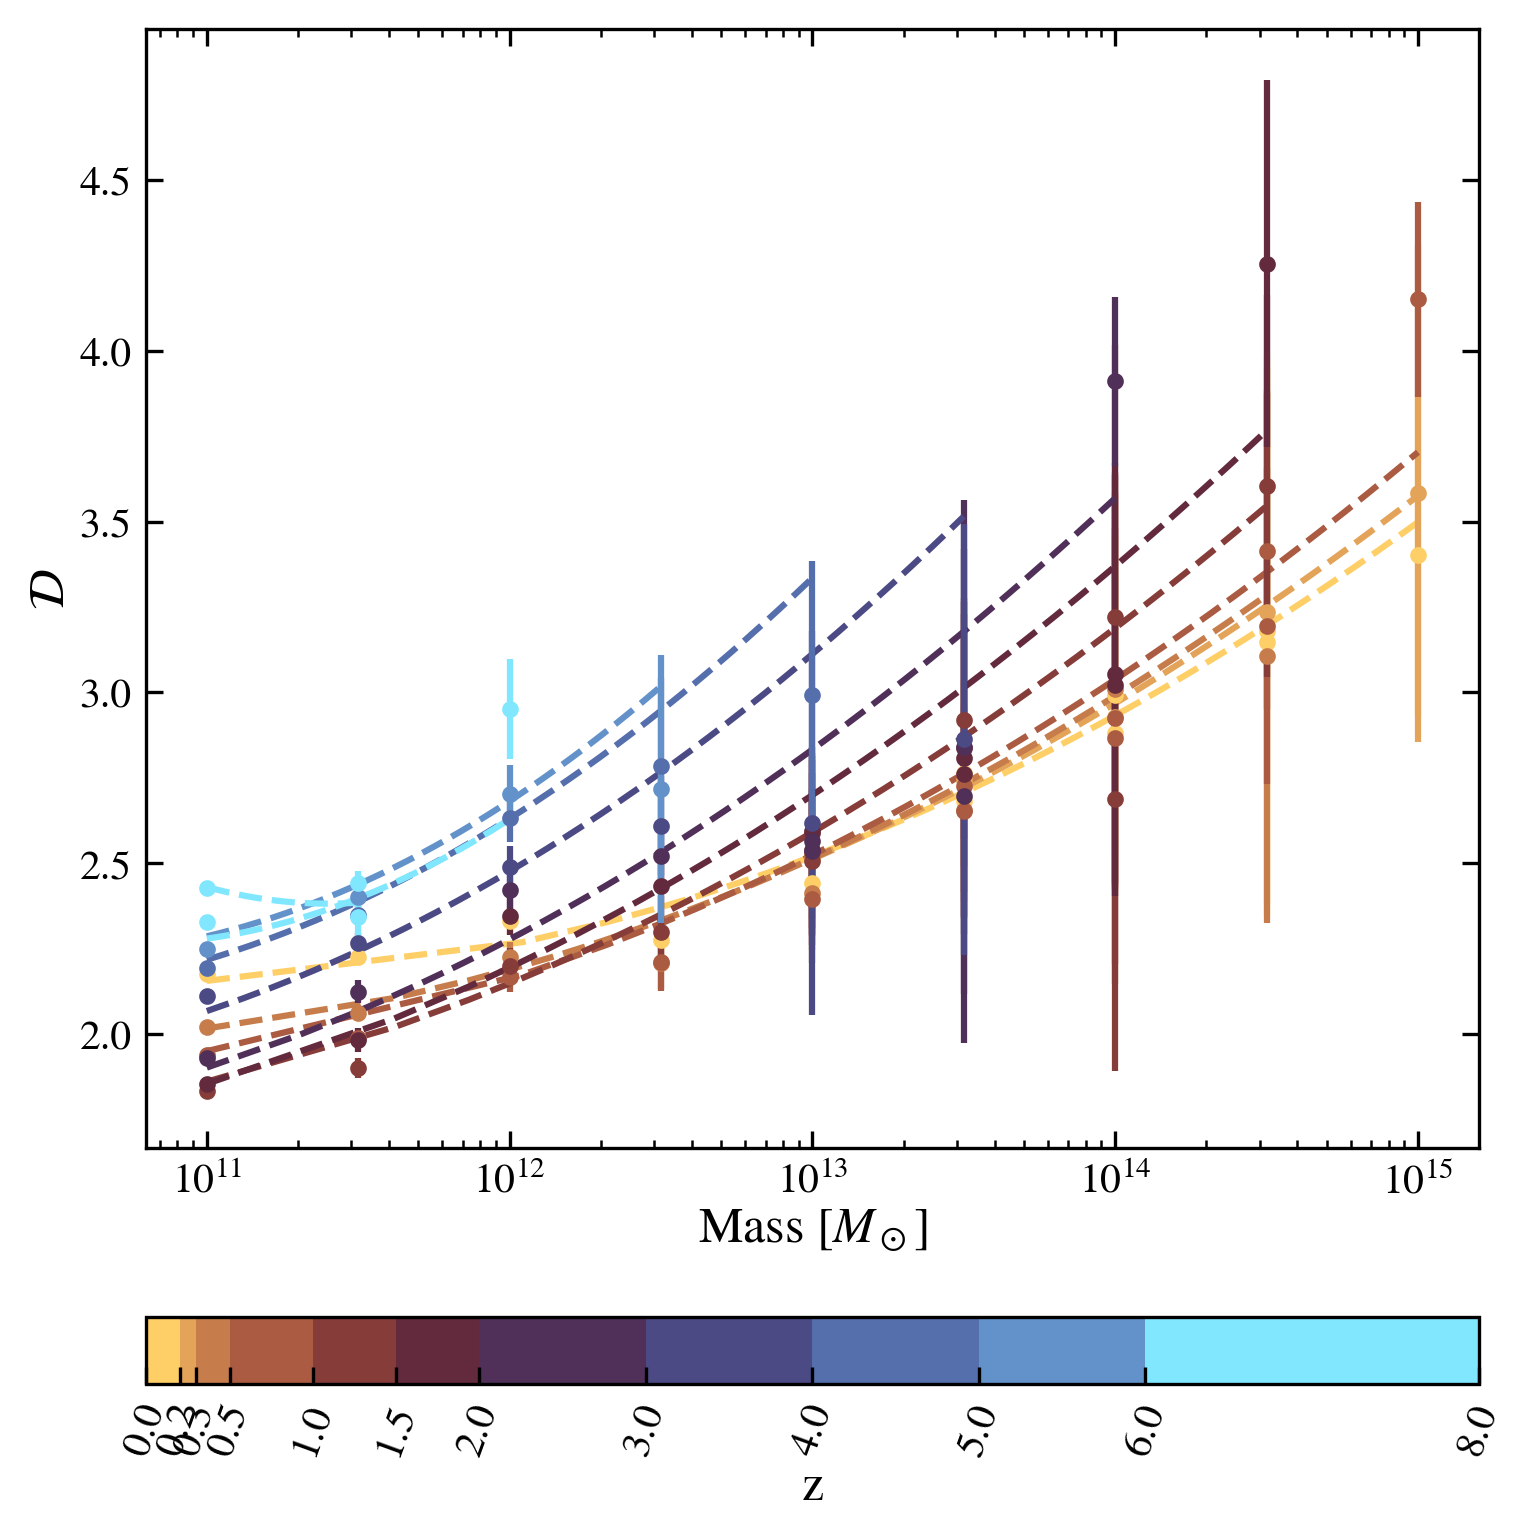

In [450]:
# Plot fitting as a function of mass
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
cmap = plt.get_cmap('managua', len(np.unique(all_z)))
norm = BoundaryNorm(np.unique(all_z), cmap.N)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                  ax=axs, orientation='horizontal', spacing='proportional', ticks=np.unique(all_z))

from matplotlib.ticker import FuncFormatter
def custom_format(x, pos):
    return f'{x:.1f}'  
cb.ax.xaxis.set_major_formatter(FuncFormatter(custom_format)) 
cb.ax.tick_params(axis='x', rotation=70) 
cb.set_label('z')

for z in np.unique(all_z):
# for z in np.unique([6.0, 8.0]):
    axs.errorbar(depth_vs_mass[z]['M'], depth_vs_mass[z]['D'], yerr=depth_vs_mass[z]['D_err'], fmt='.', color=cmap(norm(z)))
    fit_x = np.linspace(depth_vs_mass[z]['M'].min(), depth_vs_mass[z]['M'].max(), 1000)
    fit_y = fit_mass_and_z((z, np.log10(fit_x)), *popt)
    axs.plot(fit_x, fit_y, color=cmap(norm(z)), ls='--')
axs.set_xscale('log')
axs.set_xlabel('Mass [$M_\\odot$]')
axs.set_ylabel(r"$\mathcal{D}$")
plt.savefig('hydro_depth_vs_mass.png')